# Konkan Canara - Elastic Net + U-Net Hybrid Model for Temperature Prediction (4-Step Input Sequence)

In [1]:
# Importing the required libraries
import numpy as np
import joblib
import importlib
    
import random
import gc

import torch

import KC_Data_Preprocessing as KCD
import Baseline_Model_Definitions as BMD
import UNet_Model_Definitions as UMD
import Base_Test as BT

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=a73fa0eb-512f-ffe4-cf94-f2e7b26c980c, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)

In [5]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

In [6]:
torch.cuda.init()

In [7]:
gc.collect()
torch.cuda.empty_cache()

## Data Loading and Preprocessing

In [8]:
importlib.reload(KCD);

In [9]:
feature_scaler = joblib.load('feature_scaler_temp.pkl')
target_scaler = joblib.load('target_scaler_temp.pkl')

SEQ_LEN = 4

data = KCD.prepare_konkan_data(
    file_path='KC_6H_2001-2025_Final.csv', 
    feature_scaler=feature_scaler, 
    target_scaler=target_scaler, 
    seq_len=SEQ_LEN, 
    target_variable='t2m'
)

X_test, y_test = data['test']

height = data['meta']['height']
width = data['meta']['width']
num_channels = data['meta']['channels'] 
feature_names = data['meta']['feature_names']

print(f"X_test shape: {X_test.shape} (2021-2025)")

X_test shape: (7304, 4, 32, 12, 8) (2021-2025)


In [10]:
feature_names

['msl', 'sst', 'u10', 'v10', 'ws', 't2m', 'rh', 'tp']

In [11]:
height, width, num_channels

(32, 12, 8)

In [12]:
X_test_flat = X_test.reshape(X_test.shape[0], -1) 
y_test_flat = y_test.reshape(y_test.shape[0], -1)

print(f"--- Flattened Shapes for Elastic Net ---")
print(f"Test: X={X_test_flat.shape}, y={y_test_flat.shape}")

--- Flattened Shapes for Elastic Net ---
Test: X=(7304, 12288), y=(7304, 384)


## Loading the trained models

In [13]:
importlib.reload(BMD);
importlib.reload(UMD);

In [14]:
EL_MODEL_PATH = 'ElasticNet_4S_Temp.pth'

el_model = BMD.PyTorchElasticNet(input_dim=X_test_flat.shape[1], output_dim=y_test_flat.shape[1]).to(device)

try:
    el_model.load_state_dict(torch.load(EL_MODEL_PATH, map_location=device))
    el_model.eval()
    print("PyTorch Elastic Net model loaded successfully.")
except Exception as e:
    print(f"Error loading PyTorch Elastic Net model: {e}")

PyTorch Elastic Net model loaded successfully.


In [15]:
INPUT_CHANNELS_UNET = num_channels + 1
OUTPUT_CHANNELS_UNET = 2

In [16]:
UNET_MODEL_PATH1 = 'ElasticNet_Standard_U-Net_Hybrid_Temp_4S.pth'
hybrid_model1 = UMD.Standard_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET)
try:
    state_dict = torch.load(UNET_MODEL_PATH1, map_location=device)
    new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    hybrid_model1.load_state_dict(new_state_dict)
    hybrid_model1.to(device)
    hybrid_model1.eval()
    print('Standard U-Net model loaded successfully.')
except Exception as e:
    print(f'Error loading Standard U-Net: {e}')

Standard U-Net model loaded successfully.


In [17]:
UNET_MODEL_PATH2 = 'ElasticNet_Residual_U-Net_Hybrid_Temp_4S.pth'
hybrid_model2 = UMD.Residual_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET)
try:
    state_dict = torch.load(UNET_MODEL_PATH2, map_location=device)
    new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    hybrid_model2.load_state_dict(new_state_dict)
    hybrid_model2.to(device)
    hybrid_model2.eval()
    print('Residual U-Net model loaded successfully.')
except Exception as e:
    print(f'Error loading Residual U-Net: {e}')

Residual U-Net model loaded successfully.


In [18]:
UNET_MODEL_PATH3 = 'ElasticNet_Attention_U-Net_Hybrid_Temp_4S.pth'
hybrid_model3 = UMD.Attention_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET)
try:
    state_dict = torch.load(UNET_MODEL_PATH3, map_location=device)
    new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    hybrid_model3.load_state_dict(new_state_dict)
    hybrid_model3.to(device)
    hybrid_model3.eval()
    print('Attention U-Net model loaded successfully.')
except Exception as e:
    print(f'Error loading Attention U-Net: {e}')

Attention U-Net model loaded successfully.


In [19]:
UNET_MODEL_PATH4 = 'ElasticNet_CBAM_U-Net_Hybrid_Temp_4S.pth'
hybrid_model4 = UMD.CBAM_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET)
try:
    state_dict = torch.load(UNET_MODEL_PATH4, map_location=device)
    new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    hybrid_model4.load_state_dict(new_state_dict)
    hybrid_model4.to(device)
    hybrid_model4.eval()
    print('CBAM U-Net model loaded successfully.')
except Exception as e:
    print(f'Error loading CBAM U-Net: {e}')

CBAM U-Net model loaded successfully.


## Testing the model on the test set and evaluating performance

In [20]:
importlib.reload(BT);

In [21]:
MAX_HORIZON = 12
BATCH_SIZE = 128
TARGET = 't2m'
VAR = 'Temp'

### Standard U-Net

In [22]:
stan_results, stan_time = BT.evaluate_recursive_forecast_tabular(
    bs_model=el_model,
    unet_model=hybrid_model1,
    X_test=X_test,
    y_test=y_test,
    target_scaler=target_scaler,
    feature_names=feature_names,
    target_var=TARGET,
    seq_len=SEQ_LEN,
    height=height,
    width=width,
    device=device,
    max_horizon=MAX_HORIZON,
    batch_size=BATCH_SIZE
)

In [23]:
minutes, seconds = divmod(stan_time, 60)

if minutes > 0:
    print(f"Total Inference Time for Elastic Net - Standard U-Net: {int(minutes)} minutes and {seconds:.2f} seconds")
else:
    print(f"Total Inference Time for Elastic Net - Standard U-Net: {seconds:.2f} seconds")

Total Inference Time for Elastic Net - Standard U-Net: 13.59 seconds


### Residual U-Net

In [24]:
resd_results, resd_time = BT.evaluate_recursive_forecast_tabular(
    bs_model=el_model,
    unet_model=hybrid_model2,
    X_test=X_test,
    y_test=y_test,
    target_scaler=target_scaler,
    feature_names=feature_names,
    target_var=TARGET,
    seq_len=SEQ_LEN,
    height=height,
    width=width,
    device=device,
    max_horizon=MAX_HORIZON,
    batch_size=BATCH_SIZE
)

In [25]:
minutes, seconds = divmod(resd_time, 60)

if minutes > 0:
    print(f"Total Inference Time for Elastic Net - Residual U-Net: {int(minutes)} minutes and {seconds:.2f} seconds")
else:
    print(f"Total Inference Time for Elastic Net - Residual U-Net: {seconds:.2f} seconds")

Total Inference Time for Elastic Net - Residual U-Net: 13.71 seconds


### Attention U-Net

In [26]:
attn_results, attn_time = BT.evaluate_recursive_forecast_tabular(
    bs_model=el_model,
    unet_model=hybrid_model3,
    X_test=X_test,
    y_test=y_test,
    target_scaler=target_scaler,
    feature_names=feature_names,
    target_var=TARGET,
    seq_len=SEQ_LEN,
    height=height,
    width=width,
    device=device,
    max_horizon=MAX_HORIZON,
    batch_size=BATCH_SIZE
)

In [27]:
minutes, seconds = divmod(attn_time, 60)

if minutes > 0:
    print(f"Total Inference Time for Elastic Net - Attention U-Net: {int(minutes)} minutes and {seconds:.2f} seconds")
else:
    print(f"Total Inference Time for Elastic Net - Attention U-Net: {seconds:.2f} seconds")

Total Inference Time for Elastic Net - Attention U-Net: 14.67 seconds


### CBAM U-Net

In [28]:
cbam_results, cbam_time = BT.evaluate_recursive_forecast_tabular(
    bs_model=el_model,
    unet_model=hybrid_model4,
    X_test=X_test,
    y_test=y_test,
    target_scaler=target_scaler,
    feature_names=feature_names,
    target_var=TARGET,
    seq_len=SEQ_LEN,
    height=height,
    width=width,
    device=device,
    max_horizon=MAX_HORIZON,
    batch_size=BATCH_SIZE
)

In [29]:
minutes, seconds = divmod(cbam_time, 60)

if minutes > 0:
    print(f"Total Inference Time for Elastic Net - CBAM U-Net: {int(minutes)} minutes and {seconds:.2f} seconds")
else:
    print(f"Total Inference Time for Elastic Net - CBAM U-Net: {seconds:.2f} seconds")

Total Inference Time for Elastic Net - CBAM U-Net: 24.19 seconds


In [30]:
importlib.reload(BT);

In [31]:
BT.print_comparison_table('Elastic Net', SEQ_LEN, 'Temp', stan_results, resd_results, attn_results, cbam_results)

Elastic Net - U-Net Hybrid | Recursive Forecast Comparison | Temp | 4-Step Input Sequence
┌─────────────┬──────────┬───────────────┬────────────┬────────────┬─────────────┬──────────┐
│  Lead Time  │  Metric  │  Elastic Net  │  Standard  │  Residual  │  Attention  │   CBAM   │
│             │          │               │   U-Net    │   U-Net    │    U-Net    │  U-Net   │
├─────────────┼──────────┼───────────────┼────────────┼────────────┼─────────────┼──────────┤
│             │   RMSE   │    3.1661     │   0.5892   │   0.6161   │   0.5858    │  0.5926  │
├─────────────┼──────────┼───────────────┼────────────┼────────────┼─────────────┼──────────┤
│     6h      │   ACC    │    0.0106     │   0.9495   │   0.9465   │   0.9496    │  0.9485  │
├─────────────┼──────────┼───────────────┼────────────┼────────────┼─────────────┼──────────┤
│             │   CRPS   │    2.2131     │   0.2952   │   0.3114   │   0.2935    │  0.2994  │
├─────────────┼──────────┼───────────────┼────────────┼─────────

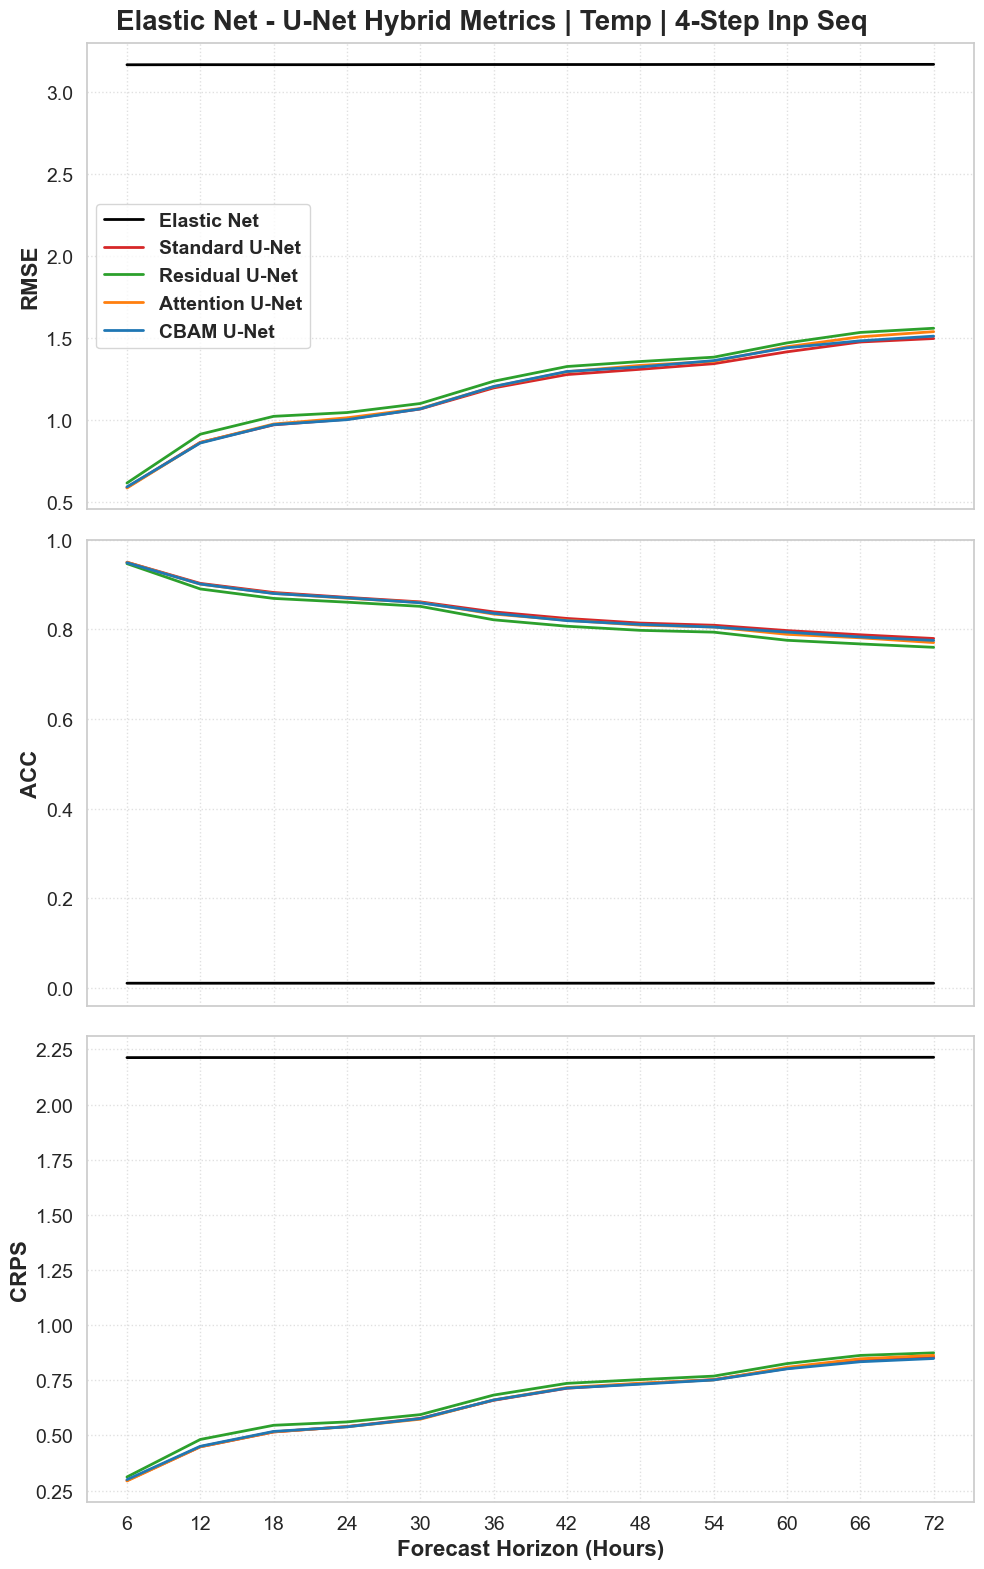

In [ ]:
BT.plot_forecast_performance(stan_results, resd_results, attn_results, cbam_results,
                             bs_md='Elastic Net', var='Temp', seq_len=SEQ_LEN, filepath='EN_HYB_Temp_PERF_PLOTS_4S.pdf')

***